
Al_R1s(r) =
+57.9571 * exp(-18.1792 r)
+32.7557 * exp(-10.8835 r)
+230.6032 * r * exp(-15.7593 r)
+0.1748 * r * exp(-5.7600 r)
-0.0306 * r * exp(-4.0085 r)
-0.0043 * r * exp(-2.8676 r)
-51.8079 * r^2 * exp(-33.5797 r)
+0.0005 * r^2 * exp(-2.1106 r)
-0.0001 * r^2 * exp(-1.3998 r)
+0.0000 * r^2 * exp(-1.0003 r)

Al_R2s(r) =
+9.4819 * exp(-18.1792 r)
-33.0592 * exp(-10.8835 r)
+62.6850 * r * exp(-15.7593 r)
+27.3123 * r * exp(-5.7600 r)
+27.8973 * r * exp(-4.0085 r)
+1.0303 * r * exp(-2.8676 r)
+24.9788 * r^2 * exp(-33.5797 r)
-0.0114 * r^2 * exp(-2.1106 r)
+0.0008 * r^2 * exp(-1.3998 r)
-0.0000 * r^2 * exp(-1.0003 r)

Al_R3s(r) =
+3.1042 * exp(-18.1792 r)
-8.5490 * exp(-10.8835 r)
+19.8670 * r * exp(-15.7593 r)
+7.2806 * r * exp(-5.7600 r)
+4.8632 * r * exp(-4.0085 r)
+2.2368 * r * exp(-2.8676 r)
+3.5155 * r^2 * exp(-33.5797 r)
-1.7493 * r^2 * exp(-2.1106 r)
-0.7497 * r^2 * exp(-1.3998 r)
-0.1207 * r^2 * exp(-1.0003 r)

Al_R2p(r) =
+14.3048 * r * exp(-14.4976 r)
+27.0339 * r * exp(-6.65

/tmp/ipykernel_21893/4002398239.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00       6.834584e-02       3.046321e-01       1.237035e+00   
1       0.05       6.834243e-02       3.043495e-01       1.218408e+00   
2       0.10       6.833222e-02       3.035037e-01       1.164410e+00   
3       0.15       6.831520e-02       3.021000e-01       1.080338e+00   
4       0.20       6.829139e-02       3.001478e-01       9.739472e-01   
...      ...                ...                ...                ...   
1996   99.80       1.879287e-07       1.299189e-08       6.948291e-10   
1997   99.85       1.870940e-07       1.293398e-08       6.917314e-10   
1998   99.90       1.862621e-07       1.287626e-08       6.886445e-10   
1999   99.95       1.854331e-07       1.281874e-08       6.855682e-10   
2000  100.00       1.846069e-07       1.276142e-08       6.825026e-10   

      J_2p_one_electron  J_3p_one_electron       J_1s(2)       J_2s(2)  \
0          1.694871e-01       9.205806e-01  1.366

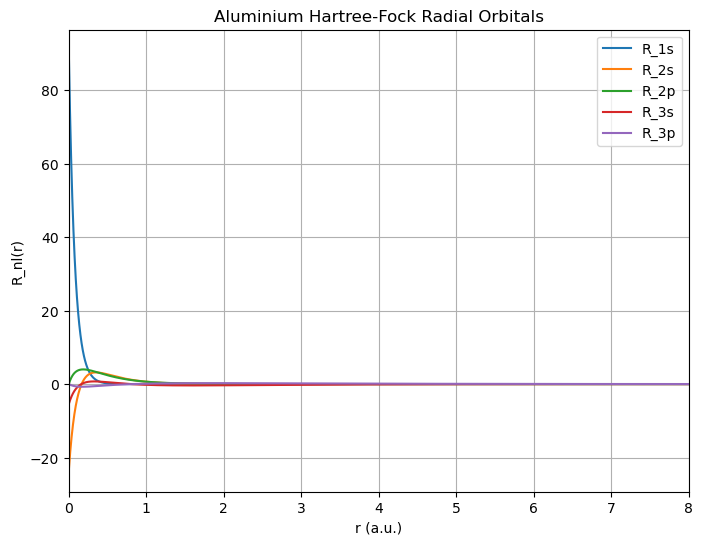

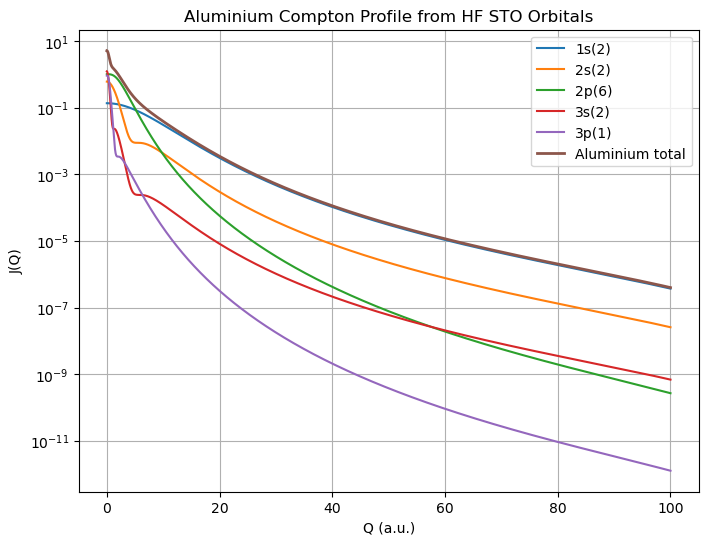

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Aluminum Hartree-Fock STO data
# Al: 1s(2) 2s(2) 2p(6) 3s(2) 3p(1)
# Format: (n_j, Z_j, C_j)
# =====================================================

aluminium_1s = [
    (1, 18.1792,  0.373865),
    (1, 10.8835,  0.456146),
    (2, 15.7593,  0.202560),
    (2,  5.7600,  0.001901),
    (2,  4.0085, -0.000823),
    (2,  2.8676, -0.000267),
    (3, 33.5797, -0.000560),
    (3,  2.1106,  0.000083),
    (3,  1.3998, -0.000044),
    (3,  1.0003,  0.000013),
]

aluminium_2s = [
    (1, 18.1792,  0.061165),
    (1, 10.8835, -0.460373),
    (2, 15.7593,  0.055062),
    (2,  5.7600,  0.297052),
    (2,  4.0085,  0.750997),
    (2,  2.8676,  0.064079),
    (3, 33.5797,  0.000270),
    (3,  2.1106, -0.001972),
    (3,  1.3998,  0.000614),
    (3,  1.0003, -0.000064),
]

aluminium_3s = [
    (1, 18.1792,  0.020024),
    (1, 10.8835, -0.119051),
    (2, 15.7593,  0.017451),
    (2,  5.7600,  0.079185),
    (2,  4.0085,  0.130917),
    (2,  2.8676,  0.139113),
    (3, 33.5797,  0.000038),
    (3,  2.1106, -0.303750),
    (3,  1.3998, -0.547941),
    (3,  1.0003, -0.285949),
]

aluminium_2p = [
    (2, 14.4976, 0.015480),
    (2,  6.6568, 0.204774),
    (2,  4.2183, 0.474317),
    (2,  3.0026, 0.339646),
    (2,  1.0822, 0.024290),
]

aluminium_3p = [
    (2, 14.4976, -0.001690),
    (2,  6.6568, -0.048903),
    (2,  4.2183, -0.058101),
    (2,  3.0026, -0.090680),
    (2,  1.0822,  0.001445),
    (3,  1.6784,  0.234760),
    (3,  1.0788,  0.496072),
    (3,  0.7494,  0.359277),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, aluminium_1s)
R2s = R_nl(r, aluminium_2s)
R3s = R_nl(r, aluminium_3s)
R2p = R_nl(r, aluminium_2p)
R3p = R_nl(r, aluminium_3p)

print_R_formula(aluminium_1s, "Al_R1s")
print_R_formula(aluminium_2s, "Al_R2s")
print_R_formula(aluminium_3s, "Al_R3s")
print_R_formula(aluminium_2p, "Al_R2p")
print_R_formula(aluminium_3p, "Al_R3p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)

# Aluminium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(1)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + J_3p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(1)": J_3p,
    
    "J_total_Alumininium": J_total
})
print(table)
table.to_csv("Aluminium_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Aluminium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_3p, label="3p(1)")
plt.plot(Q, J_total, label="Aluminium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Aluminium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()